## EDA - Weather data

#### Dataset documentation
* https://mesonet.agron.iastate.edu/request/download.phtml
* https://www.weather.gov/media/asos/aum-toc.pdf

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("s3://<BUCKET_NAME_REDACTED>/bronze/Flight_Delay_Prediction_Datasets/weather_data/weather_data.csv")

In [3]:
df.head()

,Unnamed: 0,station,valid,tmpf,dwpf,relh,sknt,gust,vsby,skyc1,skyc2,skyc3,wxcodes,p01i,alti
0,0,HTS,2025-01-01 00:51,46.00,37.00,70.64,15.00,25.00,10.00,FEW,BKN,OVC,M,0.01,29.66
1,1,SAN,2025-01-01 00:51,57.00,49.00,74.55,4.00,M,9.00,BKN,M,M,M,0.00,30.05
2,2,SGF,2025-01-01 00:52,36.00,29.00,75.46,11.00,M,10.00,OVC,M,M,M,0.00,30.14
3,3,BTR,2025-01-01 00:53,62.00,39.00,42.56,4.00,M,10.00,CLR,M,M,M,0.00,30.03
4,4,HOU,2025-01-01 00:53,64.00,40.00,41.25,4.00,M,10.00,CLR,M,M,M,0.00,30.07


In [4]:
df.shape

(2694942, 15)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2694942 entries, 0 to 2694941
Data columns (total 15 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   Unnamed: 0  int64 
 1   station     str   
 2   valid       str   
 3   tmpf        str   
 4   dwpf        str   
 5   relh        str   
 6   sknt        str   
 7   gust        str   
 8   vsby        str   
 9   skyc1       str   
 10  skyc2       str   
 11  skyc3       str   
 12  wxcodes     str   
 13  p01i        str   
 14  alti        object
dtypes: int64(1), object(1), str(13)
memory usage: 451.0+ MB


In [5]:
df.describe()

,Unnamed: 0
count,2.694942e+06
mean,1.347470e+06
std,7.779629e+05
min,0.000000e+00
25%,6.737352e+05
50%,1.347470e+06
75%,2.021206e+06
max,2.694941e+06


## Time distribution

In [9]:
df['valid'] = pd.to_datetime(df['valid'])

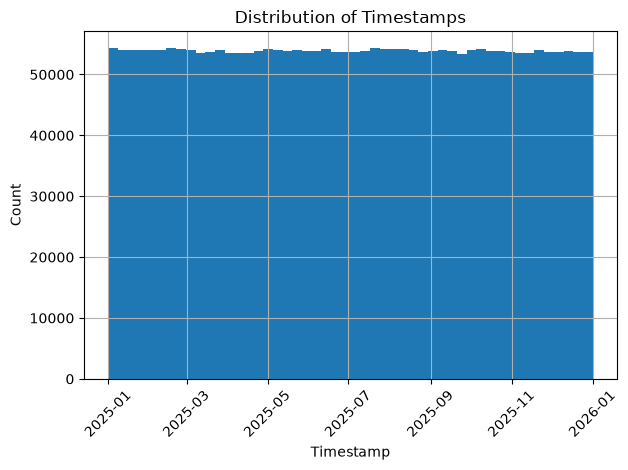

In [11]:
df["valid"].hist(bins=50)

plt.xlabel("Timestamp")
plt.ylabel("Count")
plt.title("Distribution of Timestamps")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

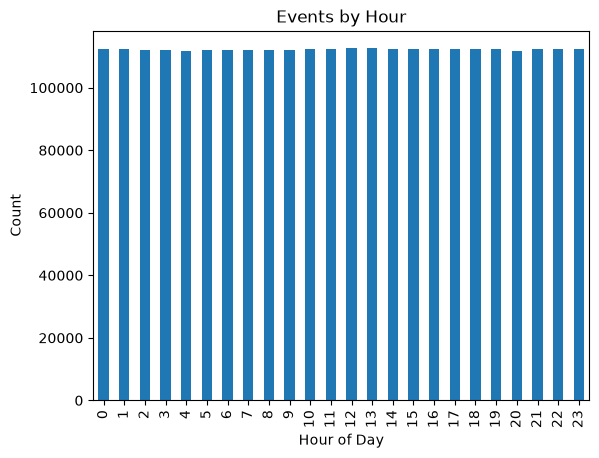

In [13]:
hour_counts = df["valid"].dt.hour.value_counts().sort_index()

hour_counts.plot(kind="bar")

plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.title("Events by Hour")
plt.show()